# FinanceBench Retrieval Benchmark Audit

Notebook nay kiem tra qua trinh bien FinanceBench QA benchmark thanh retrieval benchmark.

Muc tieu:
- Doc benchmark goc `financebench_open_source.jsonl`.
- Doc retrieval benchmark da tao: `queries.jsonl`, `qrels.jsonl`, `unmatched_evidence.jsonl`, `mapping_report.json`.
- Visual so mau, so evidence moi mau, so qrels moi query, phuong phap match.
- Doi chieu benchmark goc voi benchmark retrieval de xem mapping co hop ly khong.

Luu y: FinanceBench khong co chunk ground truth. `qrels.jsonl` la ground truth suy ra bang cach map `evidence_text` / `evidence_page_num` vao chunks cua he thong.

In [13]:
from pathlib import Path
import json
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
FINANCEBENCH_PATH = ROOT / 'benchmark/financebench/data/financebench_open_source.jsonl'
CHUNKS_PATH = ROOT / 'outputs/financebench_eval/chunks.jsonl'
QRELS_DIR = ROOT / 'outputs/financebench_eval/qrels'
QUERIES_PATH = QRELS_DIR / 'queries.jsonl'
QRELS_PATH = QRELS_DIR / 'qrels.jsonl'
UNMATCHED_PATH = QRELS_DIR / 'unmatched_evidence.jsonl'
MAPPING_REPORT_PATH = QRELS_DIR / 'mapping_report.json'

pd.set_option('display.max_colwidth', 160)

In [14]:
def load_jsonl(path: Path) -> list[dict]:
    if not path.exists() or path.stat().st_size == 0:
        return []
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

def norm_text(text: str) -> str:
    text = str(text or '').lower().replace('\u00a0', ' ')
    text = text.replace('â€”', '-').replace('—', '-').replace('–', '-')
    text = re.sub(r'[^a-z0-9$%.\-()]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def doc_key(value) -> str:
    if value is None:
        return ''
    return Path(str(value).replace('\\', '/')).stem.lower()

def chunk_text(row: dict) -> str:
    return str(row.get('text') or row.get('summary') or '')

def chunk_doc(row: dict) -> str:
    for key in ['doc_name', 'source_doc', 'source_pdf', 'source_html']:
        if row.get(key):
            return doc_key(row.get(key))
    return ''

def page_range(row: dict):
    start = row.get('page_start', row.get('page'))
    end = row.get('page_end', row.get('page'))
    try:
        start = int(start) if start is not None else None
        end = int(end) if end is not None else start
    except (TypeError, ValueError):
        return None, None
    return start, end

def page_overlap(row: dict, page) -> bool:
    if page is None:
        return False
    start, end = page_range(row)
    return start is not None and end is not None and start <= int(page) <= end

def token_recall(needle: str, haystack: str) -> float:
    n = set(re.findall(r'[a-z0-9$%.\-()]+', norm_text(needle)))
    h = set(re.findall(r'[a-z0-9$%.\-()]+', norm_text(haystack)))
    return len(n & h) / len(n) if n else 0.0

In [15]:
samples = load_jsonl(FINANCEBENCH_PATH)
chunks = load_jsonl(CHUNKS_PATH)
queries = load_jsonl(QUERIES_PATH)
qrels = load_jsonl(QRELS_PATH)
unmatched = load_jsonl(UNMATCHED_PATH)
mapping_report = json.loads(MAPPING_REPORT_PATH.read_text(encoding='utf-8')) if MAPPING_REPORT_PATH.exists() else {}

samples_df = pd.DataFrame(samples)
chunks_df = pd.DataFrame(chunks)
queries_df = pd.DataFrame(queries)
qrels_df = pd.DataFrame(qrels)
unmatched_df = pd.DataFrame(unmatched)

mapping_report

{'questions': 150,
 'chunks': 11948,
 'evidence_rows': 189,
 'qrels': 242,
 'unmatched_evidence': 0,
 'docs_with_chunks': 84,
 'evidence_rows_without_doc_chunks': 0,
 'match_method_counts': {'fuzzy_text': 161, 'exact_text': 81},
 'settings': {'fuzzy_token_threshold': 0.6,
  'fuzzy_sequence_threshold': 0.18,
  'max_fuzzy_matches': 5,
  'use_page_fallback': True,
  'evidence_page_base': 0}}

## 1. Benchmark goc: so mau va evidence moi mau

In [16]:
evidence_rows = []
for sample in samples:
    qid = str(sample['financebench_id'])
    for evidence_index, ev in enumerate(sample.get('evidence') or []):
        evidence_rows.append({
            'query_id': qid,
            'evidence_index': evidence_index,
            'doc_name': sample.get('doc_name'),
            'evidence_doc_name': doc_key(ev.get('evidence_doc_name') or ev.get('doc_name') or sample.get('doc_name')),
            'evidence_page_original': ev.get('evidence_page_num'),
            'evidence_page_one_indexed': int(ev['evidence_page_num']) + 1 if ev.get('evidence_page_num') is not None else None,
            'evidence_text': ev.get('evidence_text') or '',
            'question': sample.get('question'),
        })
evidence_df = pd.DataFrame(evidence_rows)

summary = {
    'financebench_samples': len(samples_df),
    'queries': len(queries_df),
    'evidence_rows': len(evidence_df),
    'chunks': len(chunks_df),
    'qrels': len(qrels_df),
    'unmatched_evidence': len(unmatched_df),
    'unique_docs_in_evidence': evidence_df['evidence_doc_name'].nunique(),
}
summary

{'financebench_samples': 150,
 'queries': 150,
 'evidence_rows': 189,
 'chunks': 11948,
 'qrels': 242,
 'unmatched_evidence': 0,
 'unique_docs_in_evidence': 84}

count    150.000000
mean       1.260000
std        0.497376
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: evidence_count, dtype: float64

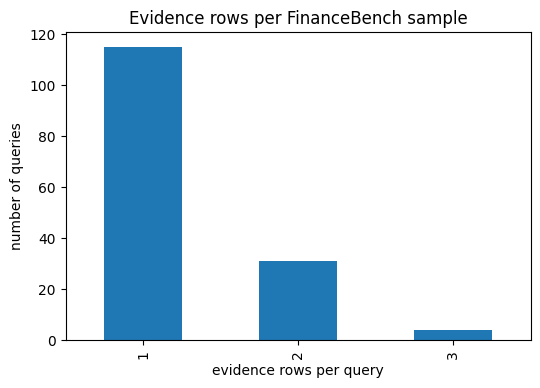

In [17]:
ev_per_query = evidence_df.groupby('query_id').size().rename('evidence_count').reset_index()
display(ev_per_query['evidence_count'].describe())

ax = ev_per_query['evidence_count'].value_counts().sort_index().plot(kind='bar', figsize=(6, 4), title='Evidence rows per FinanceBench sample')
ax.set_xlabel('evidence rows per query')
ax.set_ylabel('number of queries')
plt.show()

## 2. Doi chieu queries.jsonl voi FinanceBench goc

In [18]:
orig_queries = samples_df[['financebench_id', 'question', 'answer', 'doc_name', 'company']].rename(columns={'financebench_id': 'query_id'})
merged_queries = orig_queries.merge(queries_df, on='query_id', how='outer', suffixes=('_orig', '_retrieval'), indicator=True)
query_checks = {
    'missing_from_queries_jsonl': int((merged_queries['_merge'] == 'left_only').sum()),
    'extra_in_queries_jsonl': int((merged_queries['_merge'] == 'right_only').sum()),
    'question_mismatch': int((merged_queries['question_orig'] != merged_queries['question_retrieval']).fillna(False).sum()),
}
query_checks

{'missing_from_queries_jsonl': 0,
 'extra_in_queries_jsonl': 0,
 'question_mismatch': 0}

## 3. Doi chieu evidence goc voi qrels

In [19]:
qrel_ev = qrels_df.groupby(['query_id', 'evidence_index']).agg(
    qrel_count=('chunk_id', 'count'),
    match_methods=('match_method', lambda x: ','.join(sorted(set(x)))),
).reset_index() if not qrels_df.empty else pd.DataFrame(columns=['query_id', 'evidence_index', 'qrel_count', 'match_methods'])

evidence_audit = evidence_df.merge(qrel_ev, on=['query_id', 'evidence_index'], how='left')
evidence_audit['qrel_count'] = evidence_audit['qrel_count'].fillna(0).astype(int)
evidence_audit['is_matched'] = evidence_audit['qrel_count'] > 0

coverage = {
    'evidence_rows': len(evidence_audit),
    'matched_evidence_rows': int(evidence_audit['is_matched'].sum()),
    'unmatched_evidence_rows': int((~evidence_audit['is_matched']).sum()),
    'evidence_coverage': float(evidence_audit['is_matched'].mean()) if len(evidence_audit) else None,
}
coverage

{'evidence_rows': 189,
 'matched_evidence_rows': 189,
 'unmatched_evidence_rows': 0,
 'evidence_coverage': 1.0}

count    189.000000
mean       1.280423
std        0.627972
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        5.000000
Name: qrel_count, dtype: float64

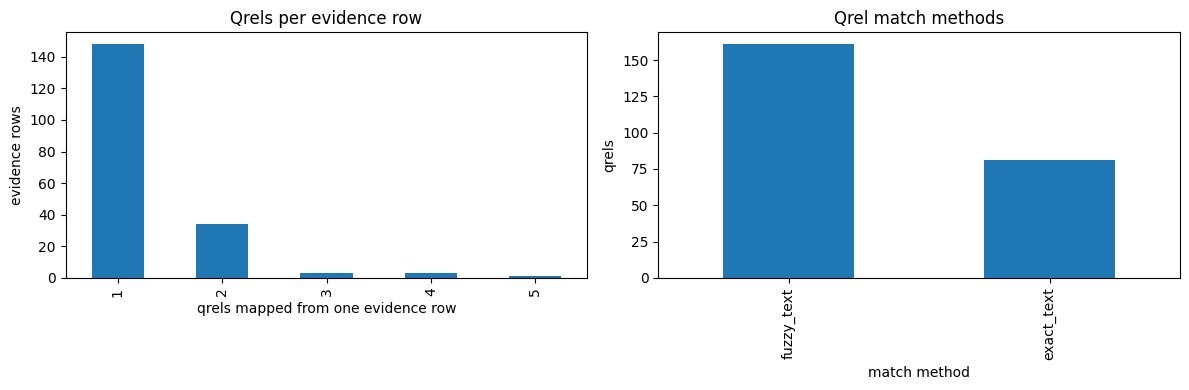

In [20]:
display(evidence_audit['qrel_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
evidence_audit['qrel_count'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Qrels per evidence row')
axes[0].set_xlabel('qrels mapped from one evidence row')
axes[0].set_ylabel('evidence rows')
qrels_df['match_method'].value_counts().plot(kind='bar', ax=axes[1], title='Qrel match methods')
axes[1].set_xlabel('match method')
axes[1].set_ylabel('qrels')
plt.tight_layout()
plt.show()

## 4. Kiem tra qrels co dung document/page/evidence khong

In [21]:
chunk_lookup = {row.get('chunk_id') or row.get('id'): row for row in chunks}
audit_rows = []
for row in qrels:
    chunk = chunk_lookup.get(row['chunk_id'], {})
    ev = evidence_df[(evidence_df['query_id'] == row['query_id']) & (evidence_df['evidence_index'] == row['evidence_index'])]
    ev_text = ev.iloc[0]['evidence_text'] if len(ev) else ''
    ctext = chunk_text(chunk)
    audit_rows.append({
        **row,
        'chunk_doc_name': chunk_doc(chunk),
        'doc_match': chunk_doc(chunk) == row.get('evidence_doc_name'),
        'page_match': page_overlap(chunk, row.get('evidence_page')),
        'exact_contains_now': norm_text(ev_text) in norm_text(ctext) if ev_text else False,
        'computed_token_recall': token_recall(ev_text, ctext),
        'chunk_page_start': page_range(chunk)[0],
        'chunk_page_end': page_range(chunk)[1],
        'chunk_text_preview': ctext[:300],
    })
qrel_audit_df = pd.DataFrame(audit_rows)

qrel_quality = {
    'qrels': len(qrel_audit_df),
    'doc_match_rate': float(qrel_audit_df['doc_match'].mean()) if len(qrel_audit_df) else None,
    'page_match_rate': float(qrel_audit_df['page_match'].mean()) if len(qrel_audit_df) else None,
    'exact_contains_rate': float(qrel_audit_df['exact_contains_now'].mean()) if len(qrel_audit_df) else None,
    'avg_token_recall': float(qrel_audit_df['computed_token_recall'].mean()) if len(qrel_audit_df) else None,
}
qrel_quality

{'qrels': 242,
 'doc_match_rate': 1.0,
 'page_match_rate': 0.78099173553719,
 'exact_contains_rate': 0.3347107438016529,
 'avg_token_recall': 0.888677957341498}

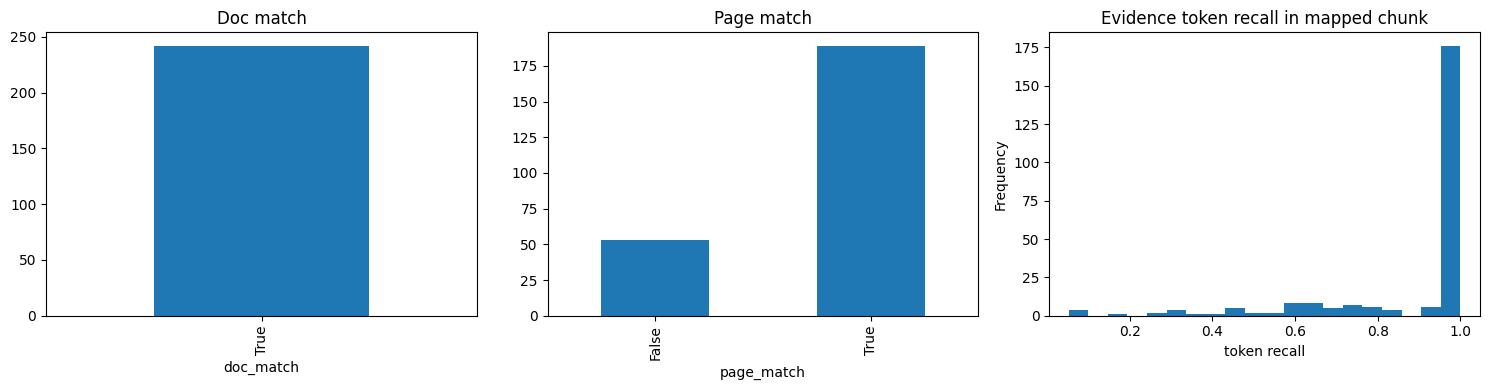

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
qrel_audit_df['doc_match'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Doc match')
qrel_audit_df['page_match'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Page match')
qrel_audit_df['computed_token_recall'].plot(kind='hist', bins=20, ax=axes[2], title='Evidence token recall in mapped chunk')
axes[2].set_xlabel('token recall')
plt.tight_layout()
plt.show()

## 5. Moi query phu hop voi cac chunk nao

In [23]:
query_chunk_rows = []
for row in qrels:
    chunk = chunk_lookup.get(row['chunk_id'], {})
    sample = samples_df[samples_df['financebench_id'] == row['query_id']]
    query_chunk_rows.append({
        'query_id': row['query_id'],
        'question': sample.iloc[0]['question'] if len(sample) else '',
        'answer': sample.iloc[0]['answer'] if len(sample) else '',
        'evidence_index': row.get('evidence_index'),
        'chunk_id': row['chunk_id'],
        'chunk_doc_name': chunk_doc(chunk),
        'chunk_page_start': page_range(chunk)[0],
        'chunk_page_end': page_range(chunk)[1],
        'evidence_page': row.get('evidence_page'),
        'match_method': row.get('match_method'),
        'match_score': row.get('match_score'),
        'token_recall': row.get('token_recall'),
        'sequence_ratio': row.get('sequence_ratio'),
        'chunk_text_preview': chunk_text(chunk)[:300],
    })

query_chunk_df = pd.DataFrame(query_chunk_rows)
query_chunk_df.head(20)

,query_id,question,answer,evidence_index,chunk_id,chunk_doc_name,chunk_page_start,chunk_page_end,evidence_page,match_method,match_score,token_recall,sequence_ratio,chunk_text_preview
0,financebench_id_03029,What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a response to the question by relying on the details shown in the cash flow sta...,$1577.00,0,fb_page_f407e03d304b570a,3m_2018_10k,60,60,60,fuzzy_text,0.999579,1.000000,0.998314,Table of Contents \n3M Company and Subsidiaries\nConsolidated Statement of Cash Flow s\nYears ended December 31\n \n(Millions)\n \n2018\n \n2017\n ...
1,financebench_id_03029,What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a response to the question by relying on the details shown in the cash flow sta...,$1577.00,0,fb_page_bda8cc11020d6b52,3m_2018_10k,46,46,60,fuzzy_text,0.534408,0.606061,0.319452,"Table of Contents \nCash Flows:\n \nCash flows from operating, investing and financing activities are provided in the tables that follow. Individual amounts..."
2,financebench_id_04672,Assume that you are a public equities analyst. Answer the following question by primarily using information that is shown in the balance sheet: what is the ...,$8.70,0,fb_page_7b50d91fbfbf17ed,3m_2018_10k,58,58,58,fuzzy_text,0.999456,1.000000,0.997825,"Table of Contents \n3M Company and Subsidiaries\nConsolidated Balance Shee t\nAt December 31\n \n \n \nDecember 31,\n \nDecember 31,\n \n(Dollars in m..."
3,financebench_id_00499,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",0,fb_page_3918eab9d6689277,3m_2022_10k,48,48,48,exact_text,1.000000,NaN,NaN,"Table of Contents\n3M Company and Subsidiaries\nConsolidated Statement of Income\nYears ended December 31\n(Millions, except per share amounts)\n2022\n2021\..."
4,financebench_id_00499,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",1,fb_page_3cf93df0cf76f9f0,3m_2022_10k,50,50,50,fuzzy_text,0.893520,1.000000,0.574081,"Table of Contents\n3M Company and Subsidiaries\nConsolidated Balance Sheet\nAt December 31\n(Dollars in millions, except per share amount)\n2022\n2021\nAsse..."
5,financebench_id_00499,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",2,fb_page_785615f3105cb92a,3m_2022_10k,52,52,52,fuzzy_text,0.902494,1.000000,0.609975,Table of Contents\n3M Company and Subsidiaries\nConsolidated Statement of Cash Flows\nYears ended December 31\n(Millions)\n2022\n2021\n2020\nCash Flows from...
6,financebench_id_00499,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",2,fb_page_8e8b56f24dd026ea,3m_2022_10k,39,39,52,fuzzy_text,0.647137,0.776860,0.257969,"Table of Contents\nCash Flows:\nCash flows from operating, investing and financing activities are provided in the tables that follow. Individual amounts in ..."
7,financebench_id_01226,"What drove operating margin change as of FY2022 for 3M? If operating margin is not a useful metric for a company like this, then please state that and expla...",Operating Margin for 3M in FY2022 has decreased by 1.7% primarily due to: \n-Decrease in gross Margin\n-mostly one-off charges including Combat Arms Earplug...,0,fb_page_8621062a3ed5cb03,3m_2022_10k,27,27,27,exact_text,1.000000,NaN,NaN,Table of Contents\nRESULTS OF OPERATIONS\nNet Sales:\nRefer to the preceding “Overview” section and the “Performance by Business Segment” se

count    150.000000
mean       1.593333
std        0.969997
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: relevant_chunk_count, dtype: float64

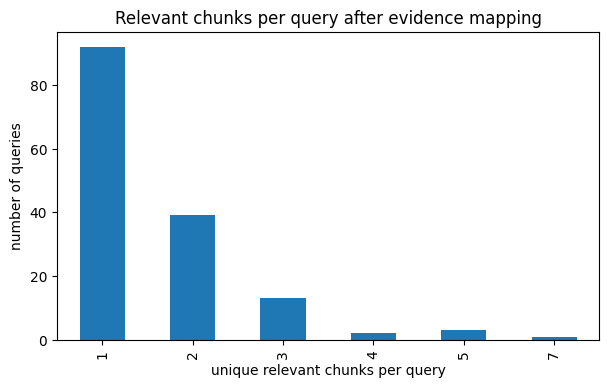

,query_id,relevant_chunk_count,qrel_count,evidence_count,match_methods,pages,question,answer,doc_name
149,financebench_id_10499,7,7,2,fuzzy_text,"50,51,52,111,113,114,115",What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,KRAFTHEINZ_2019_10K
43,financebench_id_00735,5,5,1,fuzzy_text,"12,26,117,172,213",Has Pepsico reported any materially important ongoing legal battles from FY2022 and FY2021?,"No, Pepsico is not involved in material legal battles.",PEPSICO_2022_10K
141,financebench_id_07966,5,5,2,fuzzy_text,"37,70,71,73,102",What is the FY2017 - FY2019 3 year average of capex as a % of revenue for Activision Blizzard? Answer in units of percents and round to one decimal place. C...,1.9%,ACTIVISIONBLIZZARD_2019_10K
102,financebench_id_02987,5,5,2,fuzzy_text,"37,69,70,71,102",What is the FY2019 fixed asset turnover ratio for Activision Blizzard? Fixed asset turnover ratio is defined as: FY2019 revenue / (average PP&E between FY20...,24.26,ACTIVISIONBLIZZARD_2019_10K
19,financebench_id_00499,4,4,3,"exact_text,fuzzy_text","39,48,50,52",Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",3M_2022_10K
108,financebench_id_03473,4,4,2,fuzzy_text,"49,70,74,76",What is the FY2017 return on assets (ROA) for Coca Cola? ROA is defined as: FY2017 net income / (average total assets between FY2016 and FY2017). Round your...,0.01,COCACOLA_2017_10K
148,financebench_id_10420,3,3,2,fuzzy_text,"86,130,132","Based on the information provided primarily in the statement of financial position and the statement of income, what is AES's FY2022 return on assets (ROA)?...",-0.02,AES_2022_10K
125,financebench_id_04481,3,3,2,fuzzy_text,"62,63,64",What is the FY2022 unadjusted EBITDA % margin for PepsiCo? Calculate unadjusted EBITDA using unadjusted operating income and D&A (from cash flow statement)....,16.5%,PEPSICO_2022_10K
138,financebench_id_06741,3,3,2,fuzzy_text,"30,51,56",What is the FY2018 - FY2020 3 year average unadjusted EBITDA % margin for Walmart? Define unadjusted EBITDA as unadjusted operating income + depreciation an...,6.2%,WALMART_2020_10K
71,financebench_id_01290,3,3,3,exact_text,"8,10,14",Who are the primary customers of Boeing as of FY2022?,Boeing's primary customers as of FY2022 are a limited number of commercial airlines and the US government. The US government accounted for 40% of Boeing's t...,BOEING_2022_10K


In [24]:
chunks_per_query = query_chunk_df.groupby('query_id').agg(
    relevant_chunk_count=('chunk_id', 'nunique'),
    qrel_count=('chunk_id', 'count'),
    evidence_count=('evidence_index', 'nunique'),
    match_methods=('match_method', lambda x: ','.join(sorted(set(x)))),
    pages=('chunk_page_start', lambda x: ','.join(map(str, sorted(set(x.dropna().astype(int)))))),
).reset_index()
chunks_per_query = chunks_per_query.merge(queries_df[['query_id', 'question', 'answer', 'doc_name']], on='query_id', how='left')

display(chunks_per_query['relevant_chunk_count'].describe())
ax = chunks_per_query['relevant_chunk_count'].value_counts().sort_index().plot(
    kind='bar', figsize=(7, 4), title='Relevant chunks per query after evidence mapping'
)
ax.set_xlabel('unique relevant chunks per query')
ax.set_ylabel('number of queries')
plt.show()

chunks_per_query.sort_values('relevant_chunk_count', ascending=False).head(20)

Bang `query_chunk_df` ben duoi la mapping chi tiet: moi query phu hop voi chunk nao, nam o page nao, va duoc gan bang `exact_text`, `fuzzy_text` hay `page_fallback`.

In [25]:
query_chunk_df.sort_values(['query_id', 'evidence_index', 'match_score'], ascending=[True, True, False]).head(100)

,query_id,question,answer,evidence_index,chunk_id,chunk_doc_name,chunk_page_start,chunk_page_end,evidence_page,match_method,match_score,token_recall,sequence_ratio,chunk_text_preview
115,financebench_id_00005,"Does Corning have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state t...",Yes. Corning had a positive working capital amount of $831 million by FY 2022 close. This answer considers only operating current assets and current liabili...,0,fb_page_40bf301c52badc30,corning_2022_10k,60,60,60,exact_text,1.000000,NaN,NaN,"Table of Contents\nConsolidated Balance Sheets\nCorning Incorporated and Subsidiary Companies\n \nDecember 31,\n \n(in millions, except share and per share ..."
77,financebench_id_00070,"Does American Water Works have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then p...","No, American Water Works had negative working capital of -$1561M in FY 2022.",0,fb_page_1cf431570627e43e,americanwaterworks_2022_10k,81,81,81,fuzzy_text,0.934088,1.000000,0.736353,"Table of Contents\nAmerican Water Works Company, Inc. and Subsidiary Companies\nConsolidated Balance Sheets\n(In millions, except share and per share data)\..."
78,financebench_id_00070,"Does American Water Works have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then p...","No, American Water Works had negative working capital of -$1561M in FY 2022.",1,fb_page_e20630cb62d3c40e,americanwaterworks_2022_10k,82,82,82,fuzzy_text,0.933729,1.000000,0.734916,"Table of Contents\nAmerican Water Works Company, Inc. and Subsidiary Companies\nConsolidated Balance Sheets\n(In millions, except share and per share data)\..."
79,financebench_id_00070,"Does American Water Works have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then p...","No, American Water Works had negative working capital of -$1561M in FY 2022.",1,fb_page_1cf431570627e43e,americanwaterworks_2022_10k,81,81,82,fuzzy_text,0.277757,0.305785,0.193672,"Table of Contents\nAmerican Water Works Company, Inc. and Subsidiary Companies\nConsolidated Balance Sheets\n(In millions, except share and per share data)\..."
191,financebench_id_00080,"Does Paypal have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state th...",Yes. Paypal has a positive working capital of $ 1.6Bn as of FY2022 end.,0,fb_page_2b137afcf79f5e4c,paypal_2022_10k,61,61,61,fuzzy_text,0.998050,1.000000,0.992199,"Table of Contents\nPayPal Holdings, Inc.\nCONSOLIDATED BALANCE SHEETS\n \nAs of December 31,\n2022\n2021\n \n(In millions, except par value)\nASSETS\nCurren..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,financebench_id_01244,Has CVS Health paid dividends to common shareholders in Q2 of FY2022?,"Yes, CVS paid a $ 0.55 dividend per share every quarter in FY2022",0,fb_page_edde1356b344ac52,cvshealth_2022_10k,68,68,68,exact_text,1.000000,NaN,NaN,"Table of Contents\nPART II\nItem 5. Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities.\nMarket In..."
128,financebench_id_01244,Has CVS Health paid dividends to common shareholders in Q2 of FY2022?,"Yes, CVS paid a $ 0.55 dividend per share every quarter in FY2022",0,fb_page_a7ecfdae8833bbf2,cvshealth_2022_10k,92,92,68,exact_text,1.000000,NaN,NaN,Each of the share Repurchase Programs was effective immediately and permit the Company to effect repurchases from time to time through a combination of\nope...
173,financebench_id_01254,Has MGM Resorts paid dividends to common shareholders in FY2022?,Yes. MGM maintained 0.01$ per share annual dividend through out FY 2022.,0,fb_page_2211c3c604a0a96a,mgmresorts_2022_10k,32,32,32,exact_text,1.000000,NaN,NaN,

Neu muon xem rieng mot query:

In [26]:
QUERY_ID = chunks_per_query.sort_values('relevant_chunk_count', ascending=False).iloc[0]['query_id']
print('Selected query:', QUERY_ID)
display(queries_df[queries_df['query_id'] == QUERY_ID])
display(query_chunk_df[query_chunk_df['query_id'] == QUERY_ID].sort_values(['evidence_index', 'match_score'], ascending=[True, False]))

Selected query: financebench_id_10499


,query_id,question,answer,doc_name,company,question_type,question_reasoning
99,financebench_id_10499,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,KRAFTHEINZ_2019_10K,Kraft Heinz,metrics-generated,Numerical reasoning


,query_id,question,answer,evidence_index,chunk_id,chunk_doc_name,chunk_page_start,chunk_page_end,evidence_page,match_method,match_score,token_recall,sequence_ratio,chunk_text_preview
157,financebench_id_10499,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,0,fb_page_50b3f46955197ce5,kraftheinz_2019_10k,50,50,50,fuzzy_text,0.999779,1.000000,0.999115,"The Kraft Heinz Company\nConsolidated Statements of Income\n(in millions, except per share data)\n \nDecember 28, 2019 December 29, 2018 December 30, 2017..."
158,financebench_id_10499,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,0,fb_page_5b6a6cab4efd52e9,kraftheinz_2019_10k,113,113,50,fuzzy_text,0.452244,0.540741,0.186754,"The Kraft Heinz Company\nCondensed Consolidating Statements of Income\nFor the Year Ended December 30, 2017\n(in millions)\n \nParent Guarantor \nSubsidiar..."
159,financebench_id_10499,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,0,fb_page_d4c634dc382ce383,kraftheinz_2019_10k,111,111,50,fuzzy_text,0.437583,0.518519,0.194778,"The Kraft Heinz Company\nCondensed Consolidating Statements of Income\nFor the Year Ended December 28, 2019\n(in millions)\n \nParent Guarantor \nSubsidiar..."
160,financebench_id_10499,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,0,fb_page_7aabd9f5e568870b,kraftheinz_2019_10k,51,51,50,fuzzy_text,0.308006,0.340741,0.209802,"The Kraft Heinz Company\nConsolidated Statements of Comprehensive Income\n(in millions)\n \nDecember 28, 2019 December 29, 2018 December 30, 2017\nNet inc..."
161,financebench_id_10499,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,1,fb_page_65d38f17a7d8e372,kraftheinz_2019_10k,52,52,52,fuzzy_text,0.999865,1.000000,0.999460,"The Kraft Heinz Company\nConsolidated Balance Sheets\n(in millions, except per share data)\n \nDecember 28, 2019 December 29, 2018\nASSETS\n \n \nCash and..."
162,financebench_id_10499,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,1,fb_page_3721950d21e7cd90,kraftheinz_2019_10k,115,115,52,fuzzy_text,0.507540,0.563158,0.340688,"The Kraft Heinz Company\nCondensed Consolidating Balance Sheets\nAs of December 29, 2018\n(in millions)\n \nParent Guarantor \nSubsidiary Issuer \nNon-Gua..."
163,financebench_id_10499,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,1,fb_page_ae1980b3380756f2,kraftheinz_2019_10k,114,114,52,fuzzy_text,0.471897,0.526316,0.308639,"The Kraft Heinz Company\nCondensed Consolidating Balance Sheets\nAs of December 28, 2019\n(in millions)\n \nParent Guarantor \nSubsidiary Issuer \nNon-Gua..."


## 6. Cac truong hop can xem lai

In [27]:
suspicious = qrel_audit_df[
    (~qrel_audit_df['doc_match']) |
    (~qrel_audit_df['page_match']) |
    ((qrel_audit_df['match_method'] == 'fuzzy_text') & (qrel_audit_df['computed_token_recall'] < 0.60))
].copy()
suspicious[['query_id', 'chunk_id', 'match_method', 'match_score', 'doc_match', 'page_match', 'computed_token_recall', 'evidence_doc_name', 'chunk_doc_name', 'evidence_page', 'chunk_page_start', 'chunk_page_end']].head(30)

,query_id,chunk_id,match_method,match_score,doc_match,page_match,computed_token_recall,evidence_doc_name,chunk_doc_name,evidence_page,chunk_page_start,chunk_page_end
1,financebench_id_03029,fb_page_bda8cc11020d6b52,fuzzy_text,0.534408,True,False,0.606061,3m_2018_10k,3m_2018_10k,60,46,46
6,financebench_id_00499,fb_page_8e8b56f24dd026ea,fuzzy_text,0.647137,True,False,0.776860,3m_2022_10k,3m_2022_10k,52,39,39
9,financebench_id_01865,fb_page_de8c6b332496acd5,fuzzy_text,0.453378,True,False,0.600000,3m_2022_10k,3m_2022_10k,25,33,33
15,financebench_id_02987,fb_page_085a9c3bc6fb9de0,fuzzy_text,0.571994,True,False,0.658065,activisionblizzard_2019_10k,activisionblizzard_2019_10k,70,37,37
16,financebench_id_02987,fb_page_4e187d584fa51354,fuzzy_text,0.376272,True,False,0.438710,activisionblizzard_2019_10k,activisionblizzard_2019_10k,70,102,102
17,financebench_id_02987,fb_page_64fb563441eb860e,fuzzy_text,0.257007,True,False,0.277419,activisionblizzard_2019_10k,activisionblizzard_2019_10k,70,71,71
19,financebench_id_07966,fb_page_085a9c3bc6fb9de0,fuzzy_text,0.571994,True,False,0.658065,activisionblizzard_2019_10k,activisionblizzard_2019_10k,70,37,37
20,financebench_id_07966,fb_page_4e187d584fa51354,fuzzy_text,0.376272,True,False,0.438710,activisionblizzard_2019_10k,activisionblizzard_2019_10k,70,102,102
21,financebench_id_07966,fb_page_64fb563441eb860e,fuzzy_text,0.257007,True,False,0.277419,activisionblizzard_2019_10k,activisionblizzard_2019_10k,70,71,71
31,financebench_id_01319,fb_page_fa2b15621b63a8ac,fuzzy_text,0.701993,True,False,0.840237,aes_2022_10k,aes_2022_10k,132,86,86


In [28]:
if len(unmatched_df):
    display(unmatched_df.head(20))
else:
    print('No unmatched evidence rows.')

No unmatched evidence rows.


## Shell-style quick stats: qrels theo query

Cell nay thong ke nhanh tu `qrels.jsonl`: moi query relevant voi bao nhieu `chunk_id`, phan bo so chunk relevant, va top query co nhieu chunk relevant nhat.

In [29]:
from collections import Counter, defaultdict

qrels_path = QRELS_PATH
queries_path = QUERIES_PATH

qrels_raw = load_jsonl(qrels_path)
queries_raw = load_jsonl(queries_path)
query_lookup = {row['query_id']: row for row in queries_raw}

relevant_chunks_by_query = defaultdict(set)
qrels_by_query = Counter()
methods_by_query = defaultdict(set)

for row in qrels_raw:
    qid = row['query_id']
    relevant_chunks_by_query[qid].add(row['chunk_id'])
    qrels_by_query[qid] += 1
    methods_by_query[qid].add(row.get('match_method'))

distribution = Counter(len(chunk_ids) for chunk_ids in relevant_chunks_by_query.values())

print('Total queries:', len(queries_raw))
print('Queries with qrels:', len(relevant_chunks_by_query))
print('Total qrels:', len(qrels_raw))
print('Avg relevant chunks/query:', round(sum(len(v) for v in relevant_chunks_by_query.values()) / len(queries_raw), 4))
print('\nDistribution: relevant chunk_id count -> number of queries')
for chunk_count, query_count in sorted(distribution.items()):
    print(f'{chunk_count}: {query_count}')

rows = []
for qid, chunk_ids in relevant_chunks_by_query.items():
    query = query_lookup.get(qid, {})
    rows.append({
        'query_id': qid,
        'relevant_chunk_count': len(chunk_ids),
        'qrel_count': qrels_by_query[qid],
        'match_methods': ','.join(sorted(m for m in methods_by_query[qid] if m)),
        'question': query.get('question'),
        'answer': query.get('answer'),
    })

relevant_chunks_stats_df = pd.DataFrame(rows).sort_values('relevant_chunk_count', ascending=False)
display(relevant_chunks_stats_df.head(20))

Total queries: 150
Queries with qrels: 150
Total qrels: 242
Avg relevant chunks/query: 1.5933

Distribution: relevant chunk_id count -> number of queries
1: 92
2: 39
3: 13
4: 2
5: 3
7: 1


,query_id,relevant_chunk_count,qrel_count,match_methods,question,answer
99,financebench_id_10499,7,7,fuzzy_text,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25
8,financebench_id_02987,5,5,fuzzy_text,What is the FY2019 fixed asset turnover ratio for Activision Blizzard? Fixed asset turnover ratio is defined as: FY2019 revenue / (average PP&E between FY20...,24.26
121,financebench_id_00735,5,5,fuzzy_text,Has Pepsico reported any materially important ongoing legal battles from FY2022 and FY2021?,"No, Pepsico is not involved in material legal battles."
9,financebench_id_07966,5,5,fuzzy_text,What is the FY2017 - FY2019 3 year average of capex as a % of revenue for Activision Blizzard? Answer in units of percents and round to one decimal place. C...,1.9%
2,financebench_id_00499,4,4,"exact_text,fuzzy_text",Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets..."
67,financebench_id_03473,4,4,fuzzy_text,What is the FY2017 return on assets (ROA) for Coca Cola? ROA is defined as: FY2017 net income / (average total assets between FY2016 and FY2017). Round your...,0.01
29,financebench_id_01930,3,3,fuzzy_text,"How much was the Real change in Sales for AMCOR in FY 2023 vs FY 2022, if we exclude the impact of FX movement, passthrough costs and one-off items?",The Real Growth was flat in FY 2023 vs FY 2022.
75,financebench_id_05915,3,3,fuzzy_text,What is the FY2018 fixed asset turnover ratio for CVS Health? Fixed asset turnover ratio is defined as: FY2018 revenue / (average PP&E between FY2017 and FY...,17.98
120,financebench_id_01009,3,3,"exact_text,fuzzy_text",What are the geographies that Pepsico primarily operates in as of FY2022?,"As of FY2022, Pepsico primarily operates in the following geographies: North America, Latin America, Europe, Africa, Middle East, South Asia, Asia Pacific, ..."
63,financebench_id_01290,3,3,exact_text,Who are the primary customers of Boeing as of FY2022?,Boeing's primary customers as of FY2022 are a limited number of commercial airlines and the US government. The US government accounted for 40% of Boeing's t...
